# Pipeline for synthesis, exponential

In [1]:
%matplotlib inline

# Specify CUDA device
# import os
# os.environ['CUDA_VISIBLE_DEVICES'] = 'gpu'

from jax import jit, config, grad
config.update("jax_enable_x64", True)

# Check we're running on GPU
import jax
from jax.lib import xla_bridge
print(xla_bridge.get_backend().platform)

import time
import numpy as np
import healpy as hp
import jax.numpy as jnp
import optax
import jaxopt
import pynkowski as mf
from astropy.io import fits

from matplotlib import pyplot as plt
from importlib import reload

import scatcovjax.Sphere_lib as sphlib
import scatcovjax.Synthesis_lib as synlib
import scatcovjax.Fast_scattering_lib as scatlib
from s2wav.filter_factory.filters import filters_directional_vectorised

import s2fft
import s2wav

import scatcovjax.plotting as plot
plot.notebook_plot_format()

gpu


# Setup for synthesis

In [2]:
### Parameters
sampling = "mw"
multiresolution = True
reality = True

L = 256
N = 3
J_min = 3
lam = 2.0#np.sqrt(2)
delta_j = 5
nside = int(L / 2)

if reality:
    M = L
else:
    M = 2 * L - 1

J_max = s2wav.utils.shapes.j_max(L, lam=lam)
J = J_max - J_min + 1
print(f'{J=} {J_max=}')

J=6 J_max=8


In [3]:
### Filters
filters = filters_directional_vectorised(L, N, J_min, lam=lam)
#plot.plot_filters(filters, J_min=J_min, J_max=J_max, real=True, m=L-1)
# Take the wavelets only, not the scaling function
filters = filters[0]  

In [4]:
### Weights and precomps
weights = scatlib.quadrature(L, J_min, lam, sampling, None, multiresolution)

precomps = scatlib.generate_full_precompute(L=L,
                                    N=N,
                                    J_min=J_min,
                                    lam=lam,
                                    sampling=sampling,
                                    reality=reality,
                                    multiresolution=multiresolution,
                                    nside=None)


# Target map

## Raw Healpix map

In [5]:
#sky = 'lensing'
#mapfile = '/travail/lmousset/Ulagam/kappa_00099.fits'

sky = 'tsz'
mapfile = '/travail/lmousset/NASAsimu/tSZ_skymap_healpix_nopell_Nside4096_y_tSZrescale0p75.fits'

image_file = fits.open(mapfile)
I = hp.read_map(image_file, 0, h=False)

# From nside=4096 to nside=L/2
I = hp.ud_grade(I, nside_out=nside)

## Take the log

In [6]:
mini = 0#np.min(I)
eps = 0# 1e-4

I = np.log(I - mini + eps)

## Normalize

In [7]:
mean_map = np.mean(I)
std_map = np.std(I)
print(mean_map, std_map)

I -= mean_map 
I /= std_map
print(np.mean(I), np.std(I))

print(np.min(I), np.max(I))

-13.54363 0.21842119
3.848147e-06 1.0
-2.7987976 11.843508


## Harmonic transform

Small scales are filtered out.

In [8]:
flm_target = s2fft.forward_jax(I, L, sampling='healpix', nside=nside, reality=reality)  # [L, 2L-1]

if reality:
    flm_target = flm_target[:, L - 1:]  # [L, L]

# SC coefficients of the target

In [9]:
reload(scatlib)
### P00 for normalisation
tP00_norm = scatlib.get_P00only(flm_target, L, N, J_min, lam, sampling, None,
                                reality, multiresolution, for_synthesis=False, normalisation=None,
                                filters=filters, quads=weights, precomps=precomps)  # [J][Norient]

### Scat coeffs S1, P00, C01, C11
# P00 is one because of the normalisation
tcoeffs = scatlib.scat_cov_dir(flm_target, L, N, J_min, lam, delta_j, sampling, None,
                       reality, multiresolution, for_synthesis=True, normalisation=tP00_norm,
                       filters=filters, quads=weights, precomps=precomps)

tmean, tvar, tS1, tP00, tC01, tC11 = tcoeffs  # 1D arrays

In [13]:
#plt.figure()
#plt.plot(tcumu, 'o')
#plt.yscale('log')

# Loss function

In [86]:
import relaxed
@jit
def get_hist(Ilm):
    ### Histogram
    # Make the Healpix map
    
    #I_hpx = s2fft.inverse_jax(Ilm, L=L, nside=None, sampling='mw', reality=reality)
    I_hpx = s2fft.inverse_jax(Ilm, L=L, nside=int(L / 2), sampling='healpix', reality=reality)
    #I_hpx = jnp.real(I_hpx)
    Ilm = jnp.real(jnp.ravel(I_hpx))
    #bins = jnp.linspace(jnp.min(Ilm), jnp.max(Ilm), 31)
    #hist = relaxed.hist(Ilm, bins=bins, bandwidth=1e-3)
    
    hist, _ = jnp.histogram(Ilm, bins=30, range=(-3, 3), density=True)
    return hist

#thist = get_hist(flm_target)

In [87]:
@jit
def loss_test(flm_float):
    # Make complex flm
    flm = flm_float[0, :, :] + 1j * flm_float[1, :, :]
    
    I_hpx = s2fft.inverse_jax(jnp.array(flm), L=L, nside=None, sampling='mw', reality=reality)
    I_hpx = jnp.real(jnp.ravel(I_hpx))
    hist_new, _ = jnp.histogram(I_hpx, bins=30, range=(-3, 5), density=True)
    
    loss = synlib.chi2(thist, hist_new)

    return loss

In [10]:
@jit
def loss_func(flm_float):
    # Make complex flm
    flm = flm_float[0, :, :] + 1j * flm_float[1, :, :]
    
    mean_new, var_new, S1_new, P00_new, C01_new, C11_new = scatlib.scat_cov_dir(flm, L, N, J_min, lam, delta_j, sampling,
                                                                        None, reality, multiresolution,
                                                                        for_synthesis=True,
                                                                        normalisation=tP00_norm, filters=filters,
                                                                        quads=weights, precomps=precomps)
    # Control for mean + var
    loss = synlib.chi2(tmean, mean_new)
    loss += synlib.chi2(tvar, var_new)

    # Add S1, P00, C01, C11 losses
    loss += synlib.chi2(tS1, S1_new)
    loss += synlib.chi2(tP00, P00_new)
    loss += synlib.chi2(tC01, C01_new)
    loss += synlib.chi2(tC11, C11_new)
    
    # Histogram
    #print(loss)
    #print(jnp.sum((tcumu - cumu_new)**2))
    #loss += 10*jnp.sum((tcumu - cumu_new)**2)

    return loss

# White noise in flm

0.007515444861987931


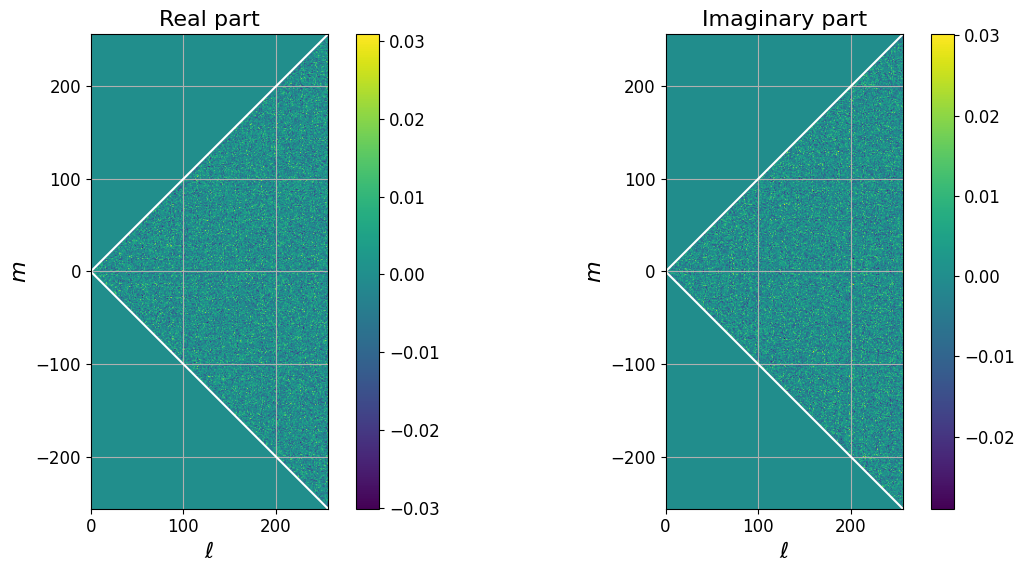

In [11]:
### STD des flm de la target
concat = np.concatenate((np.real(flm_target), np.imag(flm_target)))
sigma_bar = np.std(concat[concat!=0])
print(sigma_bar)

# Make a mask
themask = np.real(np.nan_to_num(flm_target / flm_target))  # [L, M]

### Make white noise alm
flm_imag = np.random.randn(L, M) * sigma_bar * themask
flm_real = np.random.randn(L, M) * sigma_bar * themask
flm = flm_real + 1j * flm_imag
fig = plot.plot_alm(flm)


# Run the SC synthesis

In [12]:
flm_float = jnp.array([jnp.real(flm), jnp.imag(flm)]) # [2, L, L]          

flm, loss_history = synlib.fit_jaxopt_Scipy(flm_float, loss_func, method='L-BFGS-B', niter=100, loss_history=None)

flm_end = flm[0, :, :] + 1j * flm[1, :, :]

Iter 0, Success: False, Loss = 493.95055577871517, Time = 86.07399 s/iter
Iter 10, Success: False, Loss = 83.2920363560482, Time = 0.68275 s/iter
Iter 20, Success: False, Loss = 51.497633979636205, Time = 0.33201 s/iter
Iter 30, Success: False, Loss = 32.354080048152056, Time = 0.67862 s/iter
Iter 40, Success: False, Loss = 11.707652973327448, Time = 0.41427 s/iter
Iter 50, Success: False, Loss = 9.650619619245845, Time = 0.70968 s/iter
Iter 60, Success: False, Loss = 8.409117998965552, Time = 0.33296 s/iter
Iter 70, Success: False, Loss = 5.261464524878162, Time = 0.67806 s/iter
Iter 80, Success: False, Loss = 5.07134777879204, Time = 0.33340 s/iter
Iter 90, Success: False, Loss = 4.419141535820281, Time = 0.74827 s/iter


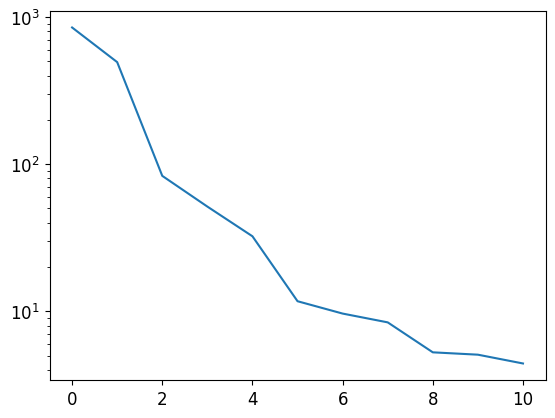

In [13]:
plt.figure()
plt.plot(loss_history)
plt.yscale('log')

# Filter large scales

In [14]:
### Cut the flm that are not contrained
lmin = int(lam**J_min)

flm_target = flm_target.at[0: lmin+1, :].set(0. + 0.j)
flm_end = flm_end.at[0: lmin+1, :].set(0. + 0.j)

# Make Hpx maps

In [15]:
### Convert the map in a Healpix map
f_target_hpx = s2fft.inverse_jax(flm_target, L, nside=nside, reality=reality, sampling='healpix')
f_end_hpx = s2fft.inverse_jax(flm_end, L, nside=nside, reality=reality, sampling='healpix')

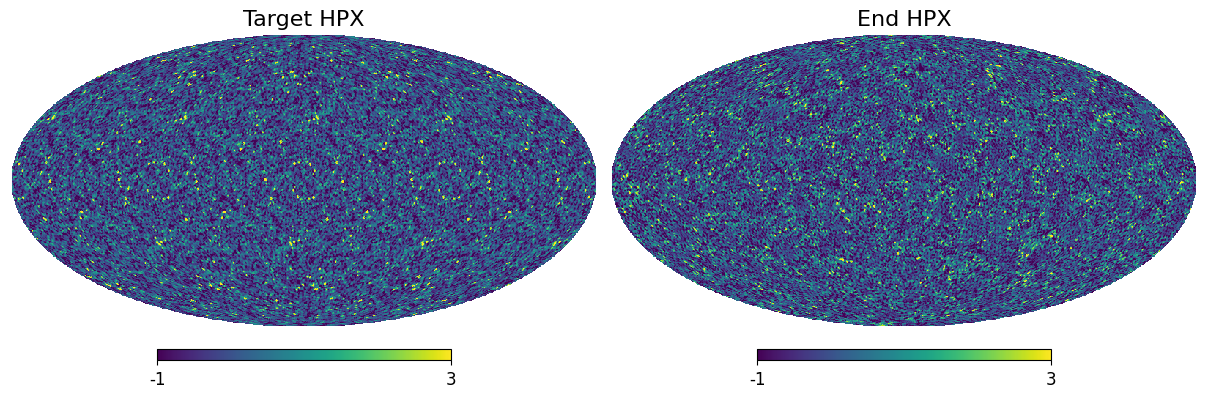

In [16]:
mn, mx = -1, 3

plt.figure(figsize=(12, 4))
hp.mollview(f_target_hpx, min=mn, max=mx, sub=(1, 2, 1), title='Target HPX')
hp.mollview(f_end_hpx, min=mn, max=mx, sub=(1, 2, 2), title='End HPX')

In [99]:
### Tune the histogram

#targ = np.copy(f_target_hpx)
#eend = np.copy(f_end_hpx)

#n = 1000

#inde = np.argpartition(eend, -n)[-n:]
#indt = np.argpartition(targ, -n)[-n:]

#eend[inde] = targ[indt]

# Stats on the log

## Histogram

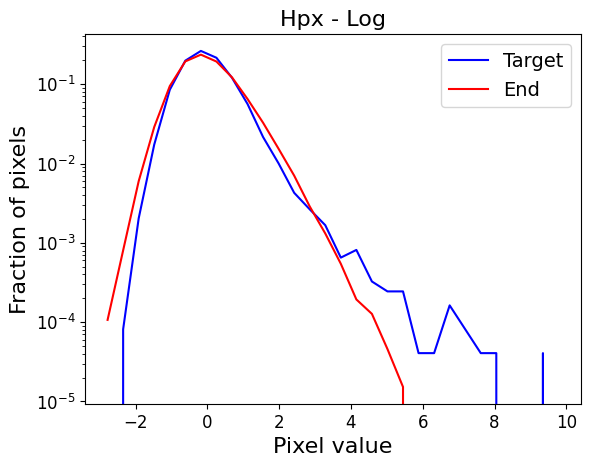

In [17]:
histrange = (-3, 10)
bins = 30

bins_centers, thist = plot.get_hist_envelop(f_target_hpx, bins=bins, range=histrange, cumulative=False)
bins_centers, ehist = plot.get_hist_envelop(f_end_hpx, bins=bins, range=histrange, cumulative=False)

bw = bins_centers[1] - bins_centers[0]

plt.figure()
plt.plot(bins_centers, thist, color='b', label='Target')
plt.plot(bins_centers, ehist, color='r', label='End')

plt.title('Hpx - Log')
plt.xlabel('Pixel value')
plt.ylabel('Fraction of pixels')
plt.legend()
plt.yscale("log")
#plt.ylim(1e-3, 1)
#plt.xlim(0, 12)

In [20]:
#f_target_E[f_target_E>0.001] = 0.001

## Power spectrum

In [18]:
ps_target = sphlib.compute_ps(flm_target, reality=False)
ps_end = sphlib.compute_ps(flm_end, reality=False)

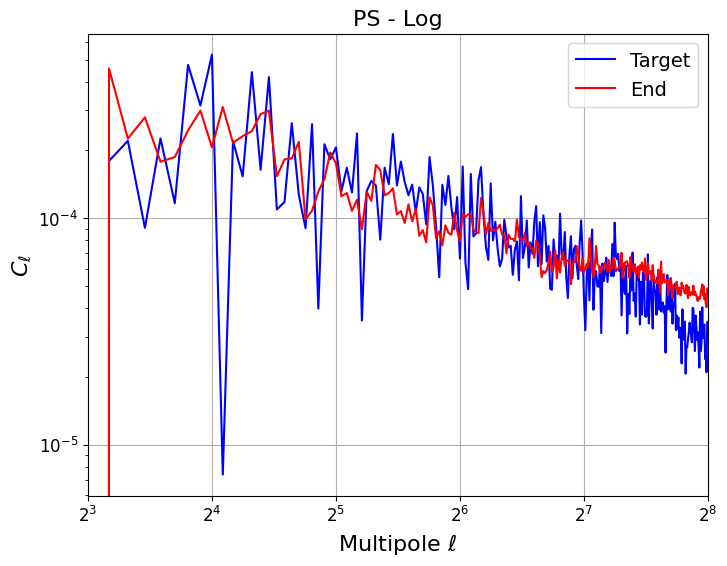

In [22]:
ell = np.arange(L)

### Plot
plt.figure(figsize=(8, 6))

plt.plot(ps_target, 'b', label="Target")
plt.plot(ps_end, 'r', label="End")


plt.title('PS - Log')
plt.yscale("log")
plt.xscale("log", base=2)
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$C_\ell$')
plt.grid()
plt.xlim(lmin, L)
#plt.ylim(1e-20, 1e-15)
plt.legend()

## Minkowski

In [25]:
def make_minkowski(us, map_hpx):

    data = mf.Healpix(map_hpx, normalise=False, mask=None)     # Default parameters
    v0 = mf.V0(data, us)
    v1 = mf.V1(data, us)
    v2 = mf.V2(data, us)
    
    return v0, v1, v2

In [26]:
#us = np.arange(0, 4e-6, 0.00000005)

us = np.arange(-5, 10, 0.1)

v0_target, v1_target, v2_target = make_minkowski(us, np.array(f_target_hpx))
v0_end, v1_end, v2_end = make_minkowski(us, np.array(f_end_hpx))

  0%|          | 0/150 [00:00<?, ?it/s]

  0%|          | 0/150 [00:00<?, ?it/s]

  0%|          | 0/150 [00:00<?, ?it/s]

  0%|          | 0/150 [00:00<?, ?it/s]

  0%|          | 0/150 [00:00<?, ?it/s]

  0%|          | 0/150 [00:00<?, ?it/s]

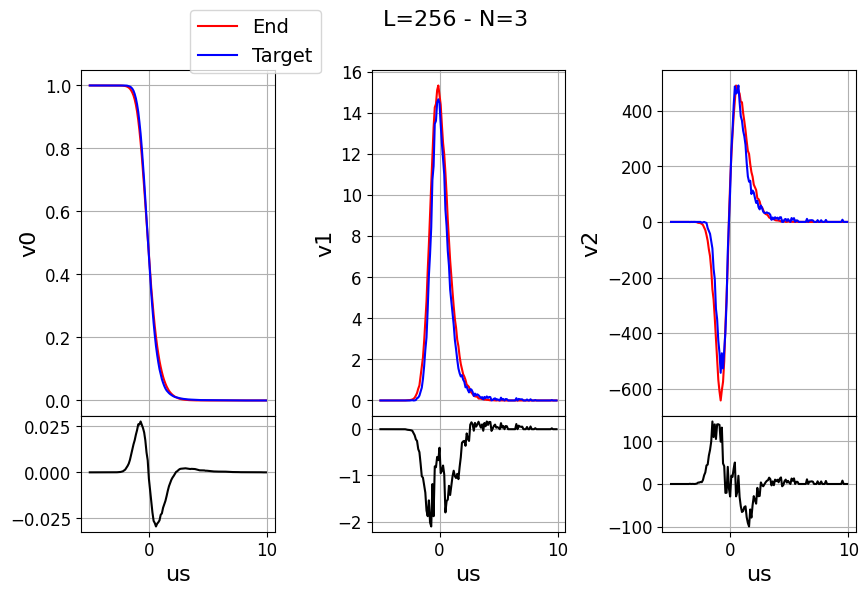

In [27]:
fig, axs = plt.subplots(2, 3, sharex='col', figsize=(10, 6), gridspec_kw={'height_ratios': [3, 1]})
axs = axs.ravel()
(ax0, ax1, ax2, ax3, ax4, ax5) = axs
fig.subplots_adjust(hspace=0, wspace=0.5)

fig.suptitle(f'{L=} - {N=}')
ns = 1
ax0.plot(us, v0_end, color='r', label=f'End')
ax0.plot(us, v0_target, color='b', label='Target')
ax0.set_ylabel('v0')
ax0.grid()
ax0.legend(loc='upper center', bbox_to_anchor=(0.9, 1.2), ncol=1, fontsize=14)

ax1.plot(us, v1_end, color='r', label='End')
ax1.plot(us, v1_target, color='b', label='Target')
ax1.set_ylabel('v1')
ax1.grid()

ax2.plot(us, v2_end, color='r', label='End')
ax2.plot(us, v2_target, color='b', label='Target')
ax2.set_ylabel('v2')
ax2.grid()
#ax2.legend()

ax3.plot(us, (v0_target - v0_end), color='k')
ax3.set_xlabel('us')
ax3.grid()

ax4.plot(us, (v1_target - v1_end), color='k')
ax4.set_xlabel('us')
ax4.grid()

ax5.plot(us, (v2_target - v2_end), color='k')
ax5.set_xlabel('us')
ax5.grid()

# Stats on the exp

## Denormalisation

In [28]:
f_target_E = f_target_hpx * std_map
f_target_E += mean_map
print(np.std(f_target_E))


f_end_E = f_end_hpx * std_map
f_end_E += mean_map
print(np.std(f_end_E))

0.1651253904797358
0.175385714118621


## Take the exponential

In [29]:
f_target_E = np.exp(f_target_E) + mini - eps
f_end_E = np.exp(f_end_E) + mini - eps

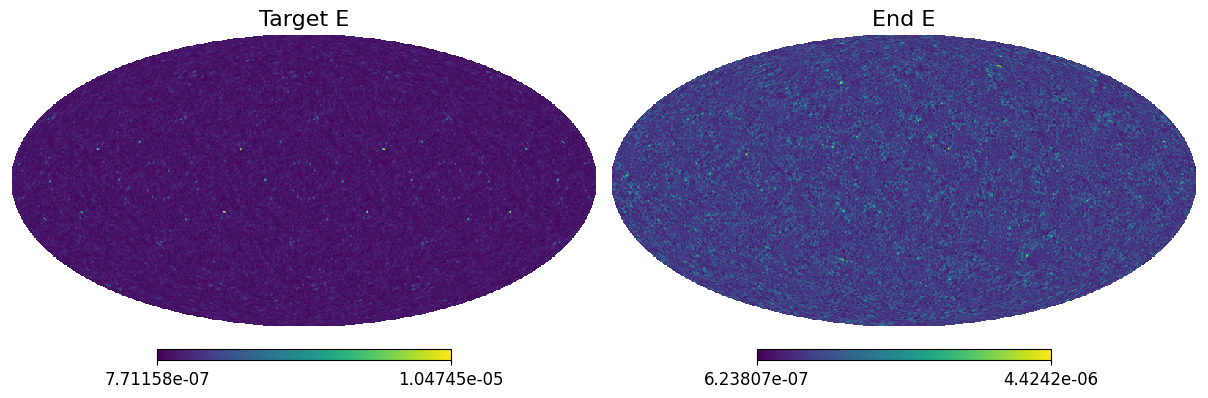

In [31]:
plt.figure(figsize=(12, 4))
hp.mollview(f_target_E, min=None, max=None, sub=(1, 2, 1), title='Target E')
hp.mollview(f_end_E, min=None, max=None, sub=(1, 2, 2), title='End E')

## PDF

In [32]:
print(np.max(f_target_E))
print(np.median(f_target_E))
print(np.mean(np.abs(f_target_E)))

(1.0474537629387492e-05+7.897354145871329e-22j)
(1.2921995911038505e-06-5.351545857482808e-23j)
1.3322404872006455e-06


In [27]:

#f_target_E[f_target_E>0.001] = 0.001
#f_target_E[f_target_E>0.0004] = np.median(f_target_E)

In [34]:
reload(plot)
histrange = (0, 1e-5)
bins = 60
density=True

bins_centers, thist = plot.get_hist_envelop(f_target_E, bins=bins, range=histrange, cumulative=False)
bins_centers, ehist = plot.get_hist_envelop(f_end_E, bins=bins, range=histrange, cumulative=False)


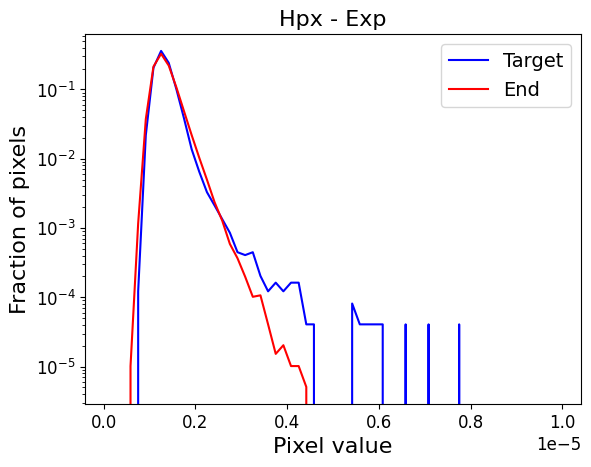

In [35]:
plt.figure()
plt.plot(bins_centers, thist, color='b', label='Target')
plt.plot(bins_centers, ehist, color='r', label='End')

plt.title('Hpx - Exp')
plt.xlabel('Pixel value')
plt.ylabel('Fraction of pixels')
plt.legend()
plt.yscale("log")
#plt.ylim(1e-3, 1)
#plt.xlim(0, 12)

## Minkoski

In [39]:
us = np.arange(0, 4e-6, 0.00000005)

v0_target, v1_target, v2_target = make_minkowski(us, np.array(f_target_E))
v0_end, v1_end, v2_end = make_minkowski(us, np.array(f_end_E))

  0%|          | 0/80 [00:00<?, ?it/s]

  0%|          | 0/80 [00:00<?, ?it/s]

  0%|          | 0/80 [00:00<?, ?it/s]

  0%|          | 0/80 [00:00<?, ?it/s]

  0%|          | 0/80 [00:00<?, ?it/s]

  0%|          | 0/80 [00:00<?, ?it/s]

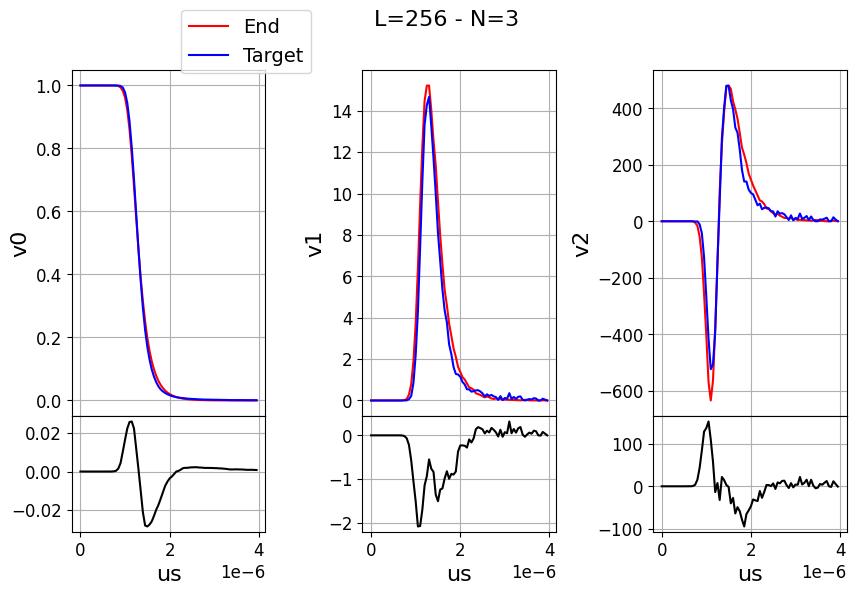

In [40]:
fig, axs = plt.subplots(2, 3, sharex='col', figsize=(10, 6), gridspec_kw={'height_ratios': [3, 1]})
axs = axs.ravel()
(ax0, ax1, ax2, ax3, ax4, ax5) = axs
fig.subplots_adjust(hspace=0, wspace=0.5)

fig.suptitle(f'{L=} - {N=}')
ns = 1
ax0.plot(us, v0_end, color='r', label=f'End')
ax0.plot(us, v0_target, color='b', label='Target')
ax0.set_ylabel('v0')
ax0.grid()
ax0.legend(loc='upper center', bbox_to_anchor=(0.9, 1.2), ncol=1, fontsize=14)

ax1.plot(us, v1_end, color='r', label='End')
ax1.plot(us, v1_target, color='b', label='Target')
ax1.set_ylabel('v1')
ax1.grid()

ax2.plot(us, v2_end, color='r', label='End')
ax2.plot(us, v2_target, color='b', label='Target')
ax2.set_ylabel('v2')
ax2.grid()
#ax2.legend()

ax3.plot(us, (v0_target - v0_end), color='k')
ax3.set_xlabel('us')
ax3.grid()

ax4.plot(us, (v1_target - v1_end), color='k')
ax4.set_xlabel('us')
ax4.grid()

ax5.plot(us, (v2_target - v2_end), color='k')
ax5.set_xlabel('us')
ax5.grid()

## Power spectrum

In [41]:
# Harmonic transform
flm_target_E = s2fft.forward_jax(f_target_E, L=L, nside=nside, reality=reality, sampling='healpix')
flm_end_E = s2fft.forward_jax(f_end_E, L=L, nside=nside, reality=reality, sampling='healpix')

In [42]:
ps_target_E = sphlib.compute_ps(flm_target_E, reality=False)
ps_end_E = sphlib.compute_ps(flm_end_E, reality=False)

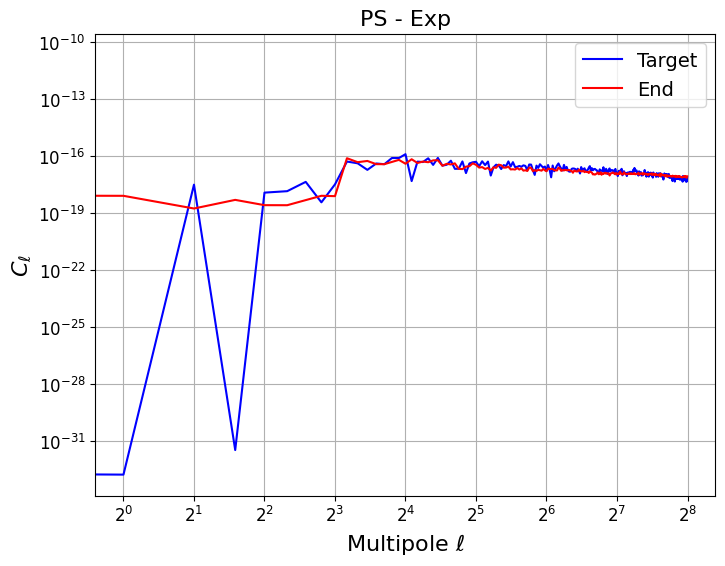

In [43]:
ell = np.arange(L)
### Plot
plt.figure(figsize=(8, 6))

plt.plot(ps_target_E, 'b', label="Target")
plt.plot(ps_end_E, 'r', label="End")

plt.title('PS - Exp')
plt.yscale("log")
plt.xscale("log", base=2)
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$C_\ell$')
plt.grid()
#plt.xlim(lmin, L)
#plt.ylim(1e-20, 1e-15)
plt.legend()